# Rumlig forudsigelse af skadestue-ventetider i et regionalt sundhedsopland med PROC KRIGE2D

## Resumé

Et driftsteam i et hospitalsnetværk måler den gennemsnitlige skadestue-ventetid (minutter) på hver bemandet facilitet i et storbyopland og ønsker en kontinuerlig ventetidsoverflade for at finde underforsynede huller til en ny akutklinik. Denne notebook genererer et syntetisk sæt på **90 geokodede faciliteter**, tilpasser en **ordinær kriging**-model med en nugget-effekt og interpolerer skadestue-ventetider over et regulært gitter, der spænder over det 50 km x 50 km store opland, hvilket giver punktforudsigelser og kriging-standardfejl ved hver gitterknude og ved tre foreslåede akutklinik-placeringer.

På tværs af de 90 faciliteter er den observerede ventetid i gennemsnit **35,5 minutter** (interval 7,5 til 58,7). Den krigede overflade genskaber dette centrum næsten præcist (gitterknude-gennemsnit **35,55 minutter**) og spænder fra **16,1** i det stille sydøst til **56,4** i det trængselsplagede nordvest, hvor de knuder med højest forudsagt ventetid klynger sig omkring midtby-belastningen. Af tre kandidat-akutklinikker forudsiger den, der ligger tættest på midtbyen, den højeste ventetid (**52,2 +/- 7,3 minutter**), hvilket gør den til det stærkeste evidensbaserede argument for placering.

## Datakilder

Alle data er syntetiske og genereret direkte i det første DATA-trin (`call streaminit(20260531)`). Der bruges ingen eksterne filer eller netværksfiler.

| Datasæt | Rækker | Variabel | Type | Beskrivelse |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | Num | Facilitetens østkoordinat i km (0-50) inden for storbyoplandets gitter |
| `ed_sites` | 90 | `north` | Num | Facilitetens nordkoordinat i km (0-50) inden for storbyoplandets gitter |
| `ed_sites` | 90 | `site_id` | Char | Facilitetsidentifikator (f.eks. `FAC037`) |
| `ed_sites` | 90 | `wait_min` | Num | Observeret gennemsnitlig skadestue-ventetid i minutter; en rumligt korreleret overflade, der kombinerer en NV-SØ-trængselsgradient, en midtby-belastning og lokal støj |

## Rumlig forudsigelse af skadestue-ventetider med PROC KRIGE2D

Et regionalt hospitalsvæsen bemander **skadestuer og akutklinikker** spredt over et 50 km x 50 km stort storbyopland. Hver facilitet rapporterer sin **gennemsnitlige skadestue-ventetid** (minutter). Ventetider er rumligt korrelerede: den trængselsplagede nordvestlige bykerne ligger højt, mens perifere sydøstlige faciliteter ligger lavere. Netværksplanlægningen ønsker en *kontinuerlig* ventetidsoverflade med usikkerhed for at identificere huller, hvor en ny akutklinik ville aflaste presset mest.

**PROC KRIGE2D** udfører todimensional ordinær kriging: den bruger en semivariogram-model til at interpolere de målte ventetider til et gitter af lokationer og returnerer både en forudsigelse og en kriging-standardfejl ved hver knude. Vi vil:

1. Generere et realistisk syntetisk facilitetsdatasæt.
2. Profilere den observerede ventetidsfordeling.
3. Krige med en sfærisk model plus nugget-effekt og undersøge overfladen.
4. Forudsige direkte ved tre kandidat-akutklinik-lokationer.

## Trin 1 - Generér syntetiske facilitetsdata

Vi spreder 90 faciliteter jævnt ud over oplandet. Den underliggende "sande" ventetidsoverflade kombinerer en glat, storskala trend (en NV-til-SØ-trængselsgradient plus en central midtby-forhøjning nær (15, 38)) med en glat regional hvirvel, så feltet er reelt rumligt autokorreleret snarere end ren støj. Vi tilføjer en lille målenugget for at efterligne dag-til-dag-variation i rapporteringen.

In [1]:
data ed_sites;
   CALL streaminit(20260531);
   LÆNGDE site_id $6;
   GØR i = 1 TIL 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* Large-scale congestion trend: high in the NW downtown core,
         tapering toward the SE suburban edge */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* Central downtown surge centered near (15, 38) */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* Smooth regional eddy to create realistic autocorrelation */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* Local reporting noise (measurement nugget) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      HVIS wait_min < 3 SÅ wait_min = 3;

      site_id = cats('FAC', put(i, z3.));
      UDDATA;
   SLUT;
   BEHOLD site_id east north wait_min;
KØR;

PROCEDURE UDSKRIV data=ed_sites(obs=10) noobs MÆRKAT;
   MÆRKAT site_id='Facilitets-id' east='Øst (km)' north='Nord (km)' wait_min='Ventetid (min)';
   TITEL 'Første 10 syntetiske skadestuefaciliteter (km-koordinater, ventetid i minutter)';
   VARIABEL site_id east north wait_min;
KØR;

                    Første 10 syntetiske skadestuefaciliteter (km-koordinater, ventetid i minutter)                     

Facilitets-id       Øst (km)      Nord (km)  Ventetid (min)
FAC001         42.1064239035  44.8746335392            36.7
FAC002         10.6189061789  14.5101311244            36.2
FAC003         48.9064287162    18.61727984            17.7
FAC004          45.555283186   43.264675772            34.5
FAC005         32.9816533373  24.7120124541            32.5
FAC006         31.1796232687  19.1168441231            31.4
FAC007         34.6664652019  35.2149577448            39.2
FAC008         40.5104234712   2.9588781811            17.1
FAC009          9.9213354522  40.5368804705            54.3
FAC010         24.5041747799  22.5897811072            35.9

... 80 more observations (showing 10 of 90)




NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Trin 2 - Profilér de observerede ventetider

Inden kriging bekræfter vi, at overfladen er fornuftigt fordelt. Et hurtigt `PROC MEANS`-sammendrag giver os det interval og den centrale tendens, som den krigede overflade bør genskabe. De 90 faciliteter har i gennemsnit **35,5 minutter** med en standardafvigelse på **10,6**, spændende fra **7,5** på den roligste forstadsfacilitet til **58,7** på den mest trængselsplagede midtbyfacilitet - en bred, realistisk spredning for et interpolationsmål.

In [2]:
PROCEDURE GENNEMSNIT data=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   MÆRKAT wait_min='Ventetid (min)';
   TITEL 'Observeret fordeling af skadestue-ventetid på tværs af faciliteter';
   VARIABEL wait_min;
KØR;

                           Observeret fordeling af skadestue-ventetid på tværs af faciliteter                           

                                                  The MEANS Procedure

 Variable  Label                 N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -------------------------------------------------------------------------------------------------------------------------------
 wait_min  Ventetid (min)       90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 -------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Trin 3 - Ordinær kriging med en sfærisk model

`COORDINATES`-sætningen navngiver de rumlige akser, `PREDICT VAR=` navngiver analysevariablen og sætter søgenaboskabet, og `MODEL` angiver semivariogrammet. Vi bruger en **sfærisk** form (et standardvalg, når korrelationen falder til nul ved en endelig rækkevidde), med:

- `SCALE=120` - den partielle sill (varians forklaret af rumlig struktur),
- `RANGE=18` - korrelationen når baggrundsniveau ved cirka 18 km,
- `NUGGET=14` - måle-/rapporteringsdiskontinuiteten ved nulafstand.

Vi interpolerer til et regulært **9 x 9 = 81-knude**-gitter, der spænder over hele oplandet (`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`) - groft nok til direkte at sammenfatte og rangere hver knude, fint nok til at kortlægge strukturen. `OUTEST=` fanger de gitterbaserede forudsigelser og standardfejl; `OUTNBHD=` registrerer, hvor mange faciliteter der indgik i hver lokal løsning. `PLOTS=` anmoder om kortet med observerede data og forudsigelseskonturen udfyldt med standardfejl.

                           Observeret fordeling af skadestue-ventetid på tværs af faciliteter                           

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


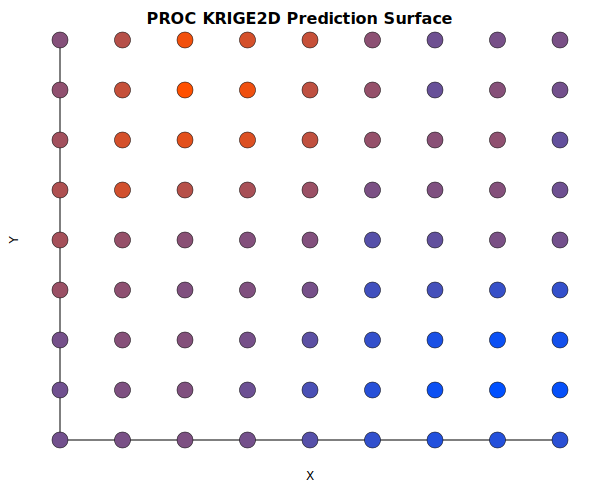

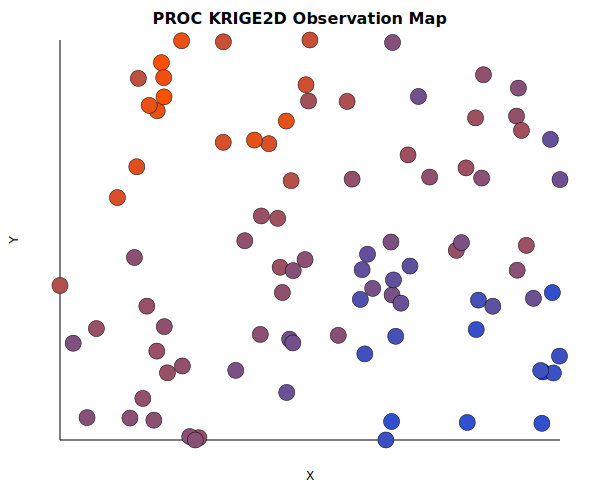

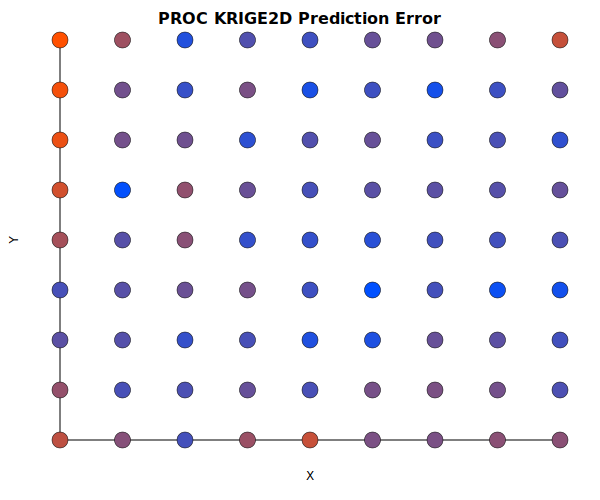

In [3]:
PROCEDURE krige2d data=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   TITEL 'Ordinær kriging af skadestue-ventetider - sfærisk model';
   COORDINATES XC=east YC=north;
   predict var=wait_min radius=20 minpoints=10 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 TIL 50 EFTER 6 y=0 TIL 50 EFTER 6;
KØR;

## Trin 4 - Undersøg den krigede overflade

`OUTEST=`-datasættet indeholder én række pr. gitterknude med den forudsagte ventetid (`estimate`) og dens kriging-standardfejl (`stderr`). Vi sammenfatter overfladen og markerer de knuder med højest forudsagt ventetid - kandidatzoner, hvor en ny akutklinik ville aflaste presset mest.

Den krigede overflades gennemsnit (**35,55 minutter**) følger næsten præcist det observerede facilitetsgennemsnit (35,5) - et fornuftstjek på, at ordinær kriging er middelret. Forudsigelser spænder fra **16,1** i det spredt bebyggede sydøst til **56,4** i det trængselsplagede nordvest; standardfejl går fra **5,1**, hvor faciliteter ligger tæt, til **11,2** i tyndt udvalgte hjørner. De seks knuder med højest ventetid ligger alle i NV-kvadranten omkring (12-18, 36-48), lige på den midtby-belastning, der er indbygget i data.

In [4]:
PROCEDURE GENNEMSNIT data=krige_sph n mean MIN MAX maxdec=2;
   MÆRKAT ESTIMATE='Estimeret ventetid (min)' stderr='Standardfejl';
   TITEL 'Sammendrag af kriget overflade (forudsagt ventetid i minutter og standardfejl)';
   VARIABEL ESTIMATE stderr;
KØR;

PROCEDURE SORTER data=krige_sph out=hot_nodes;
   EFTER FALDENDE ESTIMATE;
KØR;

PROCEDURE UDSKRIV data=hot_nodes(obs=6) noobs MÆRKAT;
   MÆRKAT x='Øst (km)' y='Nord (km)' ESTIMATE='Estimeret ventetid (min)' stderr='Standardfejl';
   TITEL 'Seks gitterknuder med de højeste forudsagte skadestue-ventetider';
   VARIABEL x y ESTIMATE stderr;
KØR;

                     Sammendrag af kriget overflade (forudsagt ventetid i minutter og standardfejl)                     

                                                  The MEANS Procedure

 Variable  Label                           N        Mean     Minimum     Maximum
 -------------------------------------------------------------------------------
 ESTIMATE  Estimeret ventetid (min)       81       35.55       16.07       56.38
 STDERR    Standardfejl                   81        7.38        5.06       11.20
 -------------------------------------------------------------------------------

                            Seks gitterknuder med de højeste forudsagte skadestue-ventetider                            

 Øst (km)  Nord (km)  Estimeret ventetid (min)  Standardfejl
       12         42             56.3838526129  6.3860887297
       12         48              54.379464215   5.876759721
       18         42               53.81777091  8.0028060667
       12         36             51


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Trin 5 - Forudsig ved specifikke kandidatlokationer

Netværksplanlægningen har tre foreslåede akutklinik-placeringer. Vi kriger direkte ved hvert punkt ved at angive det som et gitter med én knude (`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`), hvilket giver planlæggerne den forudsagte ventetid og dens kriging-standardfejl ved den nøjagtige koordinat.

Kandidaten nær midtbykernen, **(14, 37)**, giver den højeste forudsagte ventetid - **52,2 +/- 7,3 minutter** - hvilket bekræfter, at den ville absorbere efterspørgsel fra de travleste skadestuer. Sydøst-kandidaten **(32, 12)** ligger i det stille forstadshjørne med **22,0 +/- 6,2**, og nordøst-kandidaten **(42, 44)** lander i mellemklassen med **36,4 +/- 5,9**. På forudsagt ventetid alene er midtby-kandidaten det stærkeste evidensbaserede argument for placering.

In [5]:
PROCEDURE krige2d data=ed_sites outest=cand_dt PLOTS=none;
   TITEL 'Kandidat A - Centrum (14, 37)';
   COORDINATES XC=east YC=north;
   predict var=wait_min radius=20 minpoints=8 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 TIL 14 EFTER 1 y=37 TIL 37 EFTER 1;
KØR;

PROCEDURE krige2d data=ed_sites outest=cand_se PLOTS=none;
   TITEL 'Kandidat B - Forstad Sydøst (32, 12)';
   COORDINATES XC=east YC=north;
   predict var=wait_min radius=20 minpoints=8 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 TIL 32 EFTER 1 y=12 TIL 12 EFTER 1;
KØR;

PROCEDURE krige2d data=ed_sites outest=cand_ne PLOTS=none;
   TITEL 'Kandidat C - Nordøstlig udkant (42, 44)';
   COORDINATES XC=east YC=north;
   predict var=wait_min radius=20 minpoints=8 maxpoints=40;
   MODEL FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 TIL 42 EFTER 1 y=44 TIL 44 EFTER 1;
KØR;

data candidates;
   SÆT cand_dt cand_se cand_ne;
KØR;

PROCEDURE UDSKRIV data=candidates noobs MÆRKAT;
   MÆRKAT x='Øst (km)' y='Nord (km)' ESTIMATE='Estimeret ventetid (min)' stderr='Standardfejl';
   TITEL 'Forudsagte skadestue-ventetider på tre kandidat-akutklinikker';
   VARIABEL x y ESTIMATE stderr;
KØR;

                            Seks gitterknuder med de højeste forudsagte skadestue-ventetider                            

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                            Seks gitterknuder med de højeste forudsagte skadestue-ventetider                            

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## Fortolkning af resultaterne

- **Den krigede overflade genskaber oplandets trængselsstruktur.** Den sfæriske ordinær-kriging-model interpolerer et glat ventetidsfelt, hvis gitterknude-gennemsnit (35,55 min) matcher det observerede facilitetsgennemsnit (35,5 min), med de højeste forudsagte ventetider - op til 56,4 minutter - koncentreret i NV-kvadranten omkring den midtby-belastning nær (15, 38), som vi byggede ind i de syntetiske data. Denne overensstemmelse er et fornuftstjek på, at modellen opfører sig korrekt.
- **Standardfejl lokaliserer sikkerheden.** Kriging-standardfejlen spænder fra 5,1 minutter, hvor faciliteter ligger tæt, til 11,2 i de tyndt udvalgte hjørner af oplandet. Planlæggere bør behandle forudsigelser i zoner med høj `stderr` forsigtigt; det er også de områder, hvor tilføjelse af en facilitet mest ville forbedre både fremtidig dækning og fremtidig måling.
- **Punktforudsigelser understøtter placeringsbeslutninger.** Ved at krige de tre kandidatlokationer direkte bliver overfladen til en brugbar tabel. Midtby-kandidaten (14, 37) viser den højeste forudsagte ventetid (52,2 min) med en moderat standardfejl (7,3), hvilket gør den til det stærkeste evidensbaserede argument for en ny akutklinik til at aflaste den travleste skadestue; forstads-sydøst-kandidaten (32, 12) ligger i et hjørne med lav efterspørgsel (22,0 min), og nordøst-kant-kandidaten (42, 44) er i mellemklassen (36,4 min).

I praksis ville semivariogram-parametrene (`SCALE`, `RANGE`, `NUGGET`) blive estimeret empirisk med PROC VARIOGRAM og derefter givet videre til KRIGE2D - enten som eksplicitte værdier som vist her, eller automatisk via `RESTORE` fra et VARIOGRAM-item-store.